# Meaningful Representation of Sequential Data

**Authors:** Natalia Sperczyńska, 278444 and Weronika Łaszkiewicz, 278434

**Course:** Artificial Intelligence 1, W11MIP-SI0044W

**Date:** 25 May 2026

**Repository:** [github.com/wlaszkiewicz/transformers-vs-word2vec](https://github.com/wlaszkiewicz/transformers-vs-word2vec)

**Chosen task:** Illustrate with diverse examples how Transformer encoder-generated embeddings capture context, in contrast to word2vec embeddings.

## Setup

In [38]:
%pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import gensim.downloader as api
from gensim.models import Word2Vec
from transformers import BertTokenizer, BertModel

import torch

import plotly.graph_objects as go
from plotly.subplots import make_subplots

%matplotlib inline

/home/nika/Desktop/projects/transformers-vs-word2vec/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Word2Vec

Word2vec is a technique in natural language processing for obtaining words as high-dimensional vectors of numbers which capture relationships between words. In particular, words which appear in similar contexts are mapped to vectors which are nearby as measured by cosine similarity [https://en.wikipedia.org/wiki/Word2vec].

**Architectures:**

- **Continuous Bag of Words (CBOW):** Predicts the target word given its surrounding context words.
- **Skip-Gram:** Predicts the context words given a target word.

### Loading the Pretrained Model

We decided to use a pretrained model avaiable in the the Genism database [https://github.com/piskvorky/gensim-data]. We chose the `word2vec-google-news-300` model, which is a 300-dimensional vectors trained on ~100 billion words of Google News text. This gives clean, well-learned geometry without hours of training.

In [4]:
print("Downloading word2vec-google-news-300 (~1.6 GB) ...")
w2v = api.load("word2vec-google-news-300")
print(f"Loaded: {len(w2v)} words, {w2v.vector_size}-dimensional vectors")

Loaded: 3000000 words, 300-dimensional vectors


In [5]:
# word2vec-google-news-300 is already a pretrained model (CBOW architecture).
# No training needed, we can use it directly.
print(f"Vector size: {w2v.vector_size}")
print(f"Example vector shape for 'king': {w2v['king'].shape}")

Vector size: 300
Example vector shape for 'king': (300,)


### Cosine Similarity

In [6]:
pairs = [
    ("king",   "queen"),
    ("king",   "man"),
    ("dog",    "animal"),
    ("doctor", "hospital"),
    ("mole",   "freckle"),
    ("mole",   "chemistry"),
    ("mole",   "animal"),  
]

print(f'{"Word A":<12} {"Word B":<12} {"Similarity":>10}')
print("-" * 36)
for a, b in pairs:
    sim = w2v.similarity(a, b)
    print(f"{a:<12} {b:<12} {sim:>10.4f}")

Word A       Word B       Similarity
------------------------------------
king         queen            0.6511
king         man              0.2294
dog          animal           0.6438
doctor       hospital         0.5143
mole         freckle          0.4830
mole         chemistry        0.1138
mole         animal           0.1172


### Most Similar Words

In [7]:
word = "mole"

print(f'Most similar to "{word}":')
for w, score in w2v.most_similar(word, topn=10):
    print(f"  {w:<20} {score:.4f}")

Most similar to "mole":
  moles                0.6954
  pollo_en             0.5144
  freckle              0.4830
  cancerous_mole       0.4788
  birthmark            0.4661
  unibrow              0.4652
  spies                0.4557
  codenamed_Stakeknife 0.4547
  nodule               0.4531
  pube                 0.4360


### Visualization: 3D PCA

PCA is used to reduce the high-dimensional word vectors to 3D for visualization. The plot shows the target word and its most similar words based on cosine similarity in the original vector space.

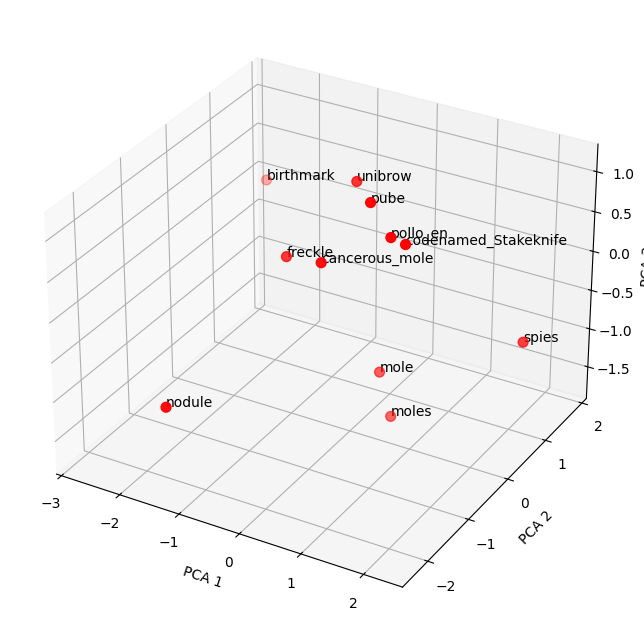

In [8]:
def plot_3D(points_3d, labels):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')

    xs = points_3d[:, 0]
    ys = points_3d[:, 1]
    zs = points_3d[:, 2]

    ax.scatter(xs, ys, zs, marker='o', c='red', s=50)

    for i, label in enumerate(labels):
        ax.text(xs[i], ys[i], zs[i], label, size=10, zorder=1, color='k')

    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.set_zlabel('PCA 3')

    plt.show()


similar_words_with_scores = w2v.most_similar(word, topn=10)
words_to_plot = [word] + [w for w, score in similar_words_with_scores]
vectors = np.array([w2v[w] for w in words_to_plot])

pca_w2v = PCA(n_components=3)
vectors_3d = pca_w2v.fit_transform(vectors)

plot_3D(vectors_3d, words_to_plot)

### Visualization: 2D PCA (word groups)

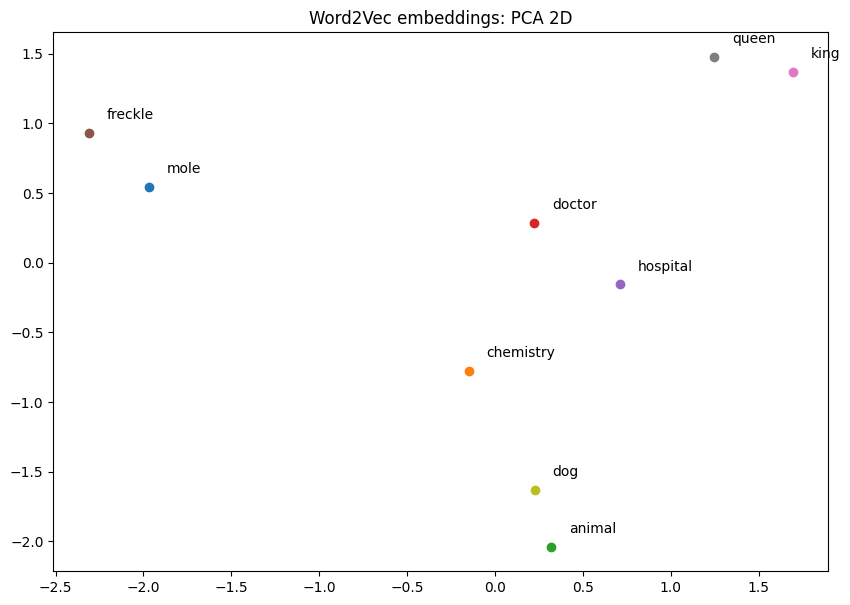

In [9]:
words = ['mole', 'chemistry', 'animal', 'doctor', 'hospital', 'freckle', 'king', 'queen', 'dog']
word_vectors = [w2v[w] for w in words]

pca = PCA(n_components=2)
word_vectors_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 7))
for w, (x, y) in zip(words, word_vectors_2d):
    plt.scatter(x, y)
    plt.text(x + 0.1, y + 0.1, w)
plt.title('Word2Vec embeddings: PCA 2D')
plt.show()


## Transformer Encoder

A Transformer encoder processes an entire input sequence simultaneously using a mechanism called **self-attention**, which allows each token to attend to every other token in the sequence. This produces a **contextual embedding**, which is a vector representation that depends not just on the word itself, but on its surrounding context. [https://en.wikipedia.org/wiki/Transformer_(deep_learning)]

This is in direct contrast to Word2Vec, which assigns a single static vector to each word regardless of context.

We decided to use **BERT** (*Bidirectional Encoder Representations from Transformers*), specifically the `bert-base-uncased` model provided by the HuggingFace `transformers` library. We chose BERT because:

- it is a **Transformer encoder** — directly matching the requirement of this task
- it processes sequences **bidirectionally**, attending to both left and right context simultaneously
- the pretrained `bert-base-uncased` model is readily available and requires no additional training
- embeddings can be extracted straightforwardly from the last hidden layer

In [10]:

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert = BertModel.from_pretrained('bert-base-uncased')
bert.eval()

def get_bert_embedding(sentence, target_word):
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    with torch.no_grad():
        outputs = bert(**inputs)
    
    hidden = outputs.last_hidden_state[0]  # (seq_len, 768)
    
    # find target word token index
    target_tokens = tokenizer.tokenize(target_word)
    for i in range(len(tokens) - len(target_tokens) + 1):
        if tokens[i:i+len(target_tokens)] == target_tokens:
            return hidden[i:i+len(target_tokens)].mean(0).numpy()
    
    raise ValueError(f"'{target_word}' not found in sentence")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1733.06it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


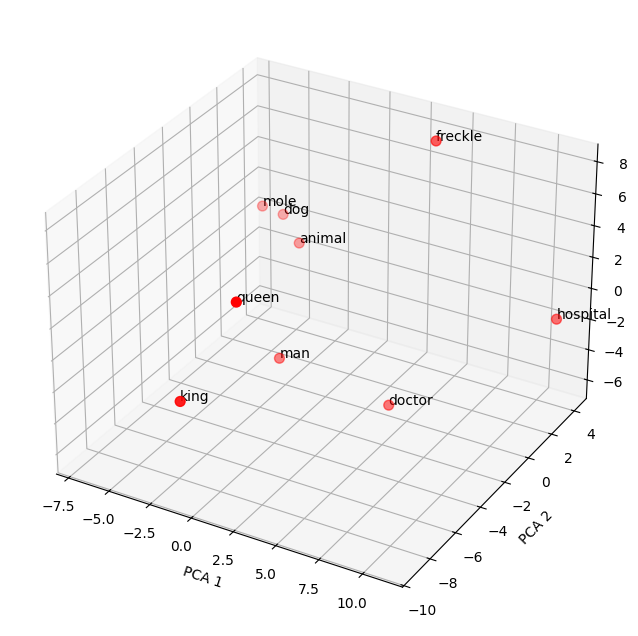

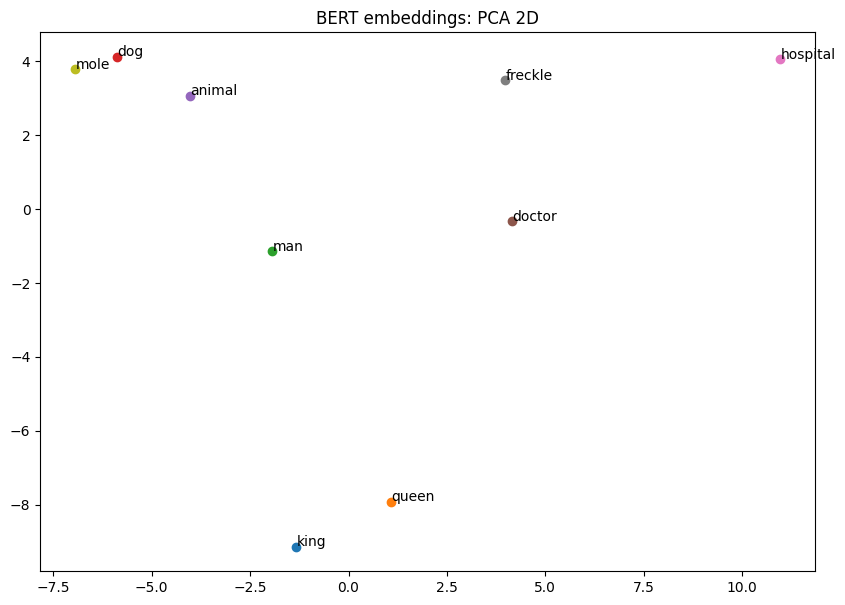

In [11]:
word_sentences = {
    'king':     'The king sat upon his throne and addressed the court.',
    'queen':    'The queen wore a golden crown at the royal ceremony.',
    'man':      'The man walked quickly through the crowded street.',
    'dog':      'The dog wagged its tail and ran across the garden.',
    'animal':   'The animal was spotted near the edge of the forest.',
    'doctor':   'The doctor examined the patient carefully before prescribing medication.',
    'hospital': 'She was rushed to the hospital after the accident.',
    'freckle':  'She had a small freckle just above her cheekbone.',
    'mole':     'The mole burrowed quickly through the soft garden soil.',  # animal sense
}

bert_vectors = np.array([get_bert_embedding(sent, word) 
                         for word, sent in word_sentences.items()])

pca = PCA(n_components=2)
bert_2d = pca.fit_transform(bert_vectors)

pca = PCA(n_components=3)
bert_3d = pca.fit_transform(bert_vectors)
plot_3D(bert_3d, list(word_sentences.keys()))

plt.figure(figsize=(10, 7))
for word, (x, y) in zip(word_sentences.keys(), bert_2d):
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)
plt.title('BERT embeddings: PCA 2D')
plt.show()

## Transformer Encoder vs. Word2Vec


In [ ]:
word_groups = {
    'king':     'royalty',
    'queen':    'royalty',
    'man':      'people',
    'dog':      'animals',
    'animal':   'animals',
    'doctor':   'medicine',
    'hospital': 'medicine',
    'freckle':  'skin',
    'mole':     'ambiguous',
}

group_colors = {
    'royalty':   '#f7a07e',
    'people':    '#7eb8f7',
    'animals':   '#a0f7b8',
    'medicine':  '#f7e07e',
    'skin':      '#d4a0f7',
    'ambiguous': '#f76e6e',
}

words = list(word_sentences.keys())

# w2v vectors
w2v_vecs = np.array([w2v[w] for w in words])
w2v_3d = PCA(n_components=3).fit_transform(w2v_vecs)

# bert vectors 
bert_3d = PCA(n_components=3).fit_transform(bert_vectors)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scatter3d'}, {'type': 'scatter3d'}]],
    subplot_titles=['Word2Vec (static)', 'BERT (contextual)']
)

for model_idx, (vecs, title) in enumerate([(w2v_3d, 'Word2Vec'), (bert_3d, 'BERT')], start=1):
    seen_groups = set()
    for i, word in enumerate(words):
        group = word_groups[word]
        color = group_colors[group]
        show_legend = group not in seen_groups
        seen_groups.add(group)

        fig.add_trace(
            go.Scatter3d(
                x=[vecs[i, 0]], y=[vecs[i, 1]], z=[vecs[i, 2]],
                mode='markers+text',
                text=[word],
                textposition='top center',
                marker=dict(size=8, color=color, opacity=0.9),
                name=group,
                legendgroup=group,
                showlegend=show_legend and model_idx == 1,
                hovertemplate=f'<b>{word}</b><br>group: {group}<extra></extra>',
            ),
            row=1, col=model_idx
        )

fig.update_layout(
    title='Word2Vec vs BERT embeddings — PCA 3D',
    height=650,
)

fig.show()

---
## Negative Example

*(TODO — see notes below)*

---
## Contributions

**Natalia Sperczyńska (278444):**

**Weronika Łaszkiewicz (278434):**

## References

Faculty of Fundamental Problems of Technology, Wrocław University of Science and Technology. *Artificial Intelligence 1 — Modelling Sequential Data*, Lecture 1.9A, available via ePortal.

**Word2Vec:**
- gensim documentation — https://radimrehurek.com/gensim/models/word2vec.html
- Wikipedia, Word2vec — https://en.wikipedia.org/wiki/Word2vec
- Alammar, J. *The Illustrated Word2Vec* — https://jalammar.github.io/illustrated-word2vec/
- https://medium.com/@datailm/word-embeddings-with-word2vec-explained-step-by-step-with-example-e70bb27ef1a0
- https://www.askpython.com/python-modules/gensim-word2vec

**Transformers:**
- Wikipedia, Transformer — https://en.wikipedia.org/wiki/Transformer_(deep_learning)
- transformers documentation - https://huggingface.co/docs/transformers/index
- Alammar, J. *The Illustrated Transformer* — https://jalammar.github.io/illustrated-transformer/
- Transformer Explainer (interactive) — https://poloclub.github.io/transformer-explainer/
- https://machinelearningmastery.com/text-embedding-generation-with-transformers/
- https://www.codegenes.net/blog/transformer-embedding-pytorch/
- https://www.nn-visual.com/transformer

---
## TODO

### Word2Vec
- [ ] Pick more interesting word pairs for cosine similarity (polysemous words work best)
- [ ] Choose a good target word for the 3D PCA — something with clear semantic neighbours
- [ ] Choose word groups for 2D PCA (e.g. royalty / science / geography / professions)
- [ ] Style the plots

### Transformer Encoder section
- [ ] Load BERT (`bert-base-uncased`)
- [ ] Write `get_bert_embedding(sentence, target_word)` helper
- [ ] Pick a polysemous word — `bank` is the classic (financial vs river)
- [ ] Write ~4-6 sentences per sense
- [ ] Extract embeddings and compute cosine similarity between them

### Comparison plots
- [ ] Cosine similarity heatmap: BERT embeddings of same word across different sentences
- [ ] Side-by-side: BERT clusters vs Word2Vec single point
- [ ] Attention heatmap (optional but looks great)

### Negative example
- [ ] Decide what the negative example is

### Admin
- [ ] Fill in contributions section
- [ ] Write `requirements.txt`
